# Mini Project 2 - TravelPayouts Routes Dataset 

## BUSINESS QUESTION & STAKEHOLDER VALUE

### MAIN BUSINESS QUESTION: (Objective)
   What factors influence route popularity/complexity?

### PROJECT APPROACH

#### This project will use REGRESSION (Module 4) to predict:
1. Primary Target: Route Popularity Score (number of airlines per route)
2. Secondary Target: Route Complexity Score (stops + code share)

#### Models to be applied:
- Linear Regression (Baseline)
- Ridge Regression (L2 Regularization)
- Lasso Regression (L1 Regularization)

### STAKEHOLDER VALUE:

  #### Airlines:
      - Optimize route planning and network expansion
      - Identify underserved vs competitive markets
      - Price optimization based on route complexity

  #### Travel Agencies:
      - Understand market connectivity patterns
      - Better itinerary planning for customers
      - Identify partnership opportunities

 ####  Airport Operators:
      - Identify partnership opportunities
      - Infrastructure investment planning
      - Hub development strategy

### Load Python Libraries

In [22]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.linear_model import Perceptron
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold


### Load and display the data

In [23]:
# Load routes data from TravelPayouts API
url_routes = "https://api.travelpayouts.com/data/en/routes.json"
response = requests.get(url_routes)
df_routes = pd.DataFrame(response.json())

In [24]:
df_routes.head()

,airline_iata,airline_icao,departure_airport_iata,departure_airport_icao,arrival_airport_iata,arrival_airport_icao,codeshare,transfers,planes
0,2B,None,AER,None,DME,None,False,0,[CR2]
1,2B,None,ASF,None,LED,None,False,0,[CR2]
2,2B,None,CEK,None,DME,None,False,0,[CR2]
3,2B,None,CEK,None,KZN,None,False,0,[CR2]
4,2B,None,CEK,None,OVB,None,False,0,[CR2]


### EDA & clean data

In [25]:
df_routes.dtypes

airline_iata              object
airline_icao              object
departure_airport_iata    object
departure_airport_icao    object
arrival_airport_iata      object
arrival_airport_icao      object
codeshare                   bool
transfers                  int64
planes                    object
dtype: object

In [26]:
df_routes.shape

(64964, 9)

In [27]:
df_routes.describe()

,transfers
count,64964.000000
mean,0.000739
std,0.027733
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


In [28]:
df_routes.isnull().sum()

airline_iata                963
airline_icao              64001
departure_airport_iata        0
departure_airport_icao    64964
arrival_airport_iata          0
arrival_airport_icao      64964
codeshare                     0
transfers                     0
planes                        0
dtype: int64

In [29]:
for col in df_routes.columns:
    try:
        print(f"   {col}: {df_routes[col].nunique():,} unique values")
    except TypeError:
        print(f"   {col}: Unable to compute (contains unhashable types)")

   airline_iata: 558 unique values
   airline_icao: 6 unique values
   departure_airport_iata: 3,325 unique values
   departure_airport_icao: 0 unique values
   arrival_airport_iata: 3,333 unique values
   arrival_airport_icao: 0 unique values
   codeshare: 2 unique values
   transfers: 3 unique values
   planes: Unable to compute (contains unhashable types)


In [30]:
# Drop ICAO columns (all are None/NaN - 100% missing)
columns_to_drop = ['airline_icao', 'departure_airport_icao', 'arrival_airport_icao']
df_routes = df_routes.drop(columns=columns_to_drop)

In [31]:
df_routes.shape

(64964, 6)

In [32]:
df_routes = df_routes.dropna(subset=['airline_iata'])

In [33]:
df_routes.isnull().sum()

airline_iata              0
departure_airport_iata    0
arrival_airport_iata      0
codeshare                 0
transfers                 0
planes                    0
dtype: int64

In [34]:
# Rename columns to match our analysis
column_renames = {
    'airline_iata': 'airline',
    'departure_airport_iata': 'source_airport',
    'arrival_airport_iata': 'destination_airport',
    'codeshare': 'code_share',
    'transfers': 'stops'
}

df_routes = df_routes.rename(columns=column_renames)

print(" Columns renamed:")
for old, new in column_renames.items():
    print(f"   {old} → {new}")

print("\n Current columns:")
print(df_routes.columns.tolist())

 Columns renamed:
   airline_iata → airline
   departure_airport_iata → source_airport
   arrival_airport_iata → destination_airport
   codeshare → code_share
   transfers → stops

 Current columns:
['airline', 'source_airport', 'destination_airport', 'code_share', 'stops', 'planes']


### Creating Features

In [35]:
# Convert code_share to binary (True/False to 1/0)
df_routes['code_share'] = df_routes['code_share'].astype(int)

# Create route popularity score (number of airlines operating this route)
route_popularity = df_routes.groupby(['source_airport', 'destination_airport'])['airline'].nunique().reset_index()
route_popularity.columns = ['source_airport', 'destination_airport', 'route_popularity_score']
df_routes = df_routes.merge(route_popularity, on=['source_airport', 'destination_airport'], how='left')

# Create route frequency (total flights on this route)
route_frequency = df_routes.groupby(['source_airport', 'destination_airport']).size().reset_index(name='route_frequency')
df_routes = df_routes.merge(route_frequency, on=['source_airport', 'destination_airport'], how='left')

# Create complexity score (stops + code_share)
df_routes['complexity_score'] = df_routes['stops'] + df_routes['code_share']

# Airline-level features (how many routes each airline operates)
airline_route_count = df_routes.groupby('airline').size().reset_index(name='airline_total_routes')
df_routes = df_routes.merge(airline_route_count, on='airline', how='left')

# Airport hub size (outgoing routes from each airport)
airport_outgoing = df_routes.groupby('source_airport').size().reset_index(name='outgoing_routes')
df_routes = df_routes.merge(airport_outgoing, on='source_airport', how='left')

# Airport hub size (incoming routes to each airport)
airport_incoming = df_routes.groupby('destination_airport').size().reset_index(name='incoming_routes')
df_routes = df_routes.merge(airport_incoming, left_on='destination_airport', right_on='destination_airport', how='left')

# Fill NaN values for incoming_routes (airports with no incoming? should be 0)
df_routes['incoming_routes'] = df_routes['incoming_routes'].fillna(0)

# Hub connectivity (total routes through this airport)
df_routes['hub_connectivity'] = df_routes['outgoing_routes'] + df_routes['incoming_routes']

print(f"\n New features created:")
print(f"   - route_popularity_score: Number of airlines per route")
print(f"   - route_frequency: Total flights on this route")
print(f"   - complexity_score: Stops + Code Share")
print(f"   - airline_total_routes: Routes per airline")
print(f"   - outgoing_routes: Routes from origin airport")
print(f"   - incoming_routes: Routes to destination airport")
print(f"   - hub_connectivity: Total airport connectivity")

print(f"\n Final dataset shape: {df_routes.shape}")

# Display sample of new features
print("\n Sample of engineered features:")
print(df_routes[['airline', 'source_airport', 'destination_airport', 'stops', 'code_share', 
                  'complexity_score', 'route_popularity_score', 'airline_total_routes', 
                  'outgoing_routes', 'incoming_routes', 'hub_connectivity']].head(10))


 New features created:
   - route_popularity_score: Number of airlines per route
   - route_frequency: Total flights on this route
   - complexity_score: Stops + Code Share
   - airline_total_routes: Routes per airline
   - outgoing_routes: Routes from origin airport
   - incoming_routes: Routes to destination airport
   - hub_connectivity: Total airport connectivity

 Final dataset shape: (64001, 13)

 Sample of engineered features:
  airline source_airport destination_airport  stops  code_share  \
0      2B            AER                 DME      0           0   
1      2B            ASF                 LED      0           0   
2      2B            CEK                 DME      0           0   
3      2B            CEK                 KZN      0           0   
4      2B            CEK                 OVB      0           0   
5      2B            DME                 AER      0           0   
6      2B            DME                 CEK      0           0   
7      2B            DME 

### Target varibles distribution analysis

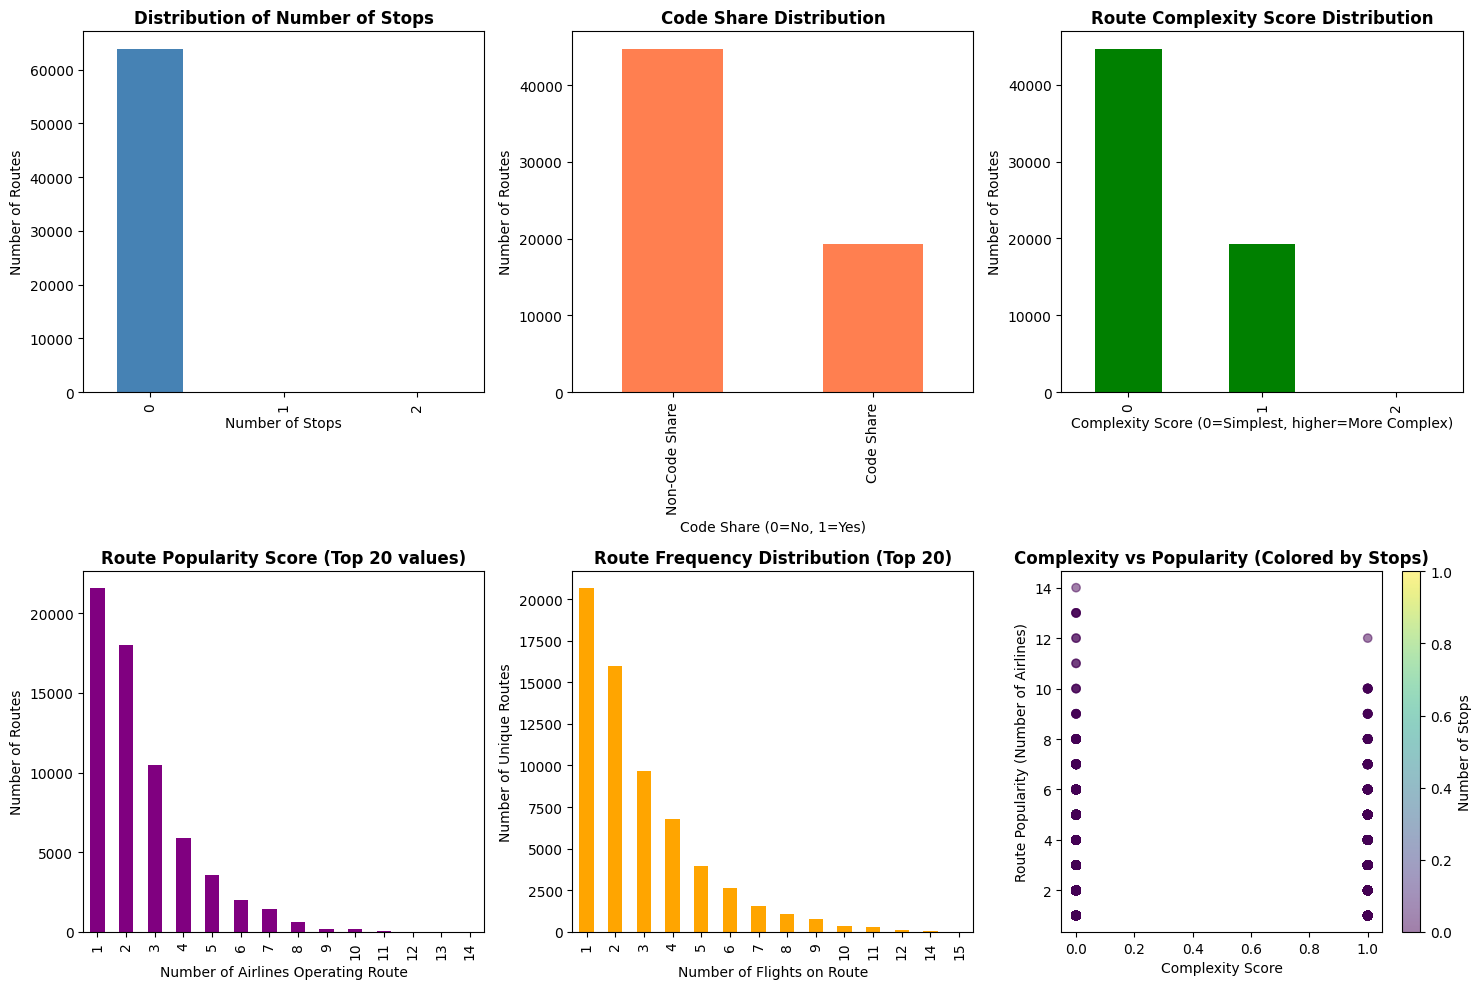

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Stops Distribution
ax1 = axes[0, 0]
df_routes['stops'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Distribution of Number of Stops', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Stops')
ax1.set_ylabel('Number of Routes')

# 2. Code Share Distribution
ax2 = axes[0, 1]
df_routes['code_share'].value_counts().plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Code Share Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Code Share (0=No, 1=Yes)')
ax2.set_ylabel('Number of Routes')
ax2.set_xticklabels(['Non-Code Share', 'Code Share'])

# 3. Complexity Score Distribution
ax3 = axes[0, 2]
df_routes['complexity_score'].value_counts().sort_index().plot(kind='bar', ax=ax3, color='green')
ax3.set_title('Route Complexity Score Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Complexity Score (0=Simplest, higher=More Complex)')
ax3.set_ylabel('Number of Routes')

# 4. Route Popularity Score Distribution
ax4 = axes[1, 0]
popularity_counts = df_routes['route_popularity_score'].value_counts().sort_index()
popularity_counts.head(20).plot(kind='bar', ax=ax4, color='purple')
ax4.set_title('Route Popularity Score (Top 20 values)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Number of Airlines Operating Route')
ax4.set_ylabel('Number of Routes')

# 5. Route Frequency Distribution
ax5 = axes[1, 1]
df_routes['route_frequency'].value_counts().sort_index().head(20).plot(kind='bar', ax=ax5, color='orange')
ax5.set_title('Route Frequency Distribution (Top 20)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Number of Flights on Route')
ax5.set_ylabel('Number of Unique Routes')

# 6. Popularity vs Complexity Scatter Plot
ax6 = axes[1, 2]
sample_data = df_routes.sample(min(5000, len(df_routes)))
scatter = ax6.scatter(sample_data['complexity_score'], sample_data['route_popularity_score'], 
                      alpha=0.5, c=sample_data['stops'], cmap='viridis')
ax6.set_title('Complexity vs Popularity (Colored by Stops)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Complexity Score')
ax6.set_ylabel('Route Popularity (Number of Airlines)')
plt.colorbar(scatter, ax=ax6, label='Number of Stops')

plt.tight_layout()
plt.show()


### Outcome

In [38]:
print("\n Reasoning:")
print("1. Directly answers 'popularity' aspect of the main question")
print("2. Continuous variable suitable for regression")
print("3. Business relevance: More airlines = More competitive market")
print("4. Can be predicted using route characteristics")
print("5. Helps airlines identify underserved vs competitive routes")

# Define primary target variable
primary_target = 'route_popularity_score'
print(f"\n Primary target varible: {primary_target}")
print(f"   Mean: {df_routes[primary_target].mean():.2f}")
print(f"   Median: {df_routes[primary_target].median():.2f}")
print(f"   Min: {df_routes[primary_target].min()}")
print(f"   Max: {df_routes[primary_target].max()}")


 Reasoning:
1. Directly answers 'popularity' aspect of the main question
2. Continuous variable suitable for regression
3. Business relevance: More airlines = More competitive market
4. Can be predicted using route characteristics
5. Helps airlines identify underserved vs competitive routes

 Primary target varible: route_popularity_score
   Mean: 2.53
   Median: 2.00
   Min: 1
   Max: 14


### Feature selection for modeling

In [39]:
# Select features for the model
feature_columns = [
    'stops',
    'code_share', 
    'airline_total_routes',
    'outgoing_routes',
    'incoming_routes',
    'hub_connectivity'
]

print("\n Selected Features:")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i}. {col}")

# Verify no missing values in features
print("\n Checking for missing values in features:")
for col in feature_columns:
    missing = df_routes[col].isnull().sum()
    if missing > 0:
        print(f"    {col}: {missing} missing values - Filling with 0")
        df_routes[col] = df_routes[col].fillna(0)
    else:
        print(f"   {col}: No missing values")


 Selected Features:
   1. stops
   2. code_share
   3. airline_total_routes
   4. outgoing_routes
   5. incoming_routes
   6. hub_connectivity

 Checking for missing values in features:
   stops: No missing values
   code_share: No missing values
   airline_total_routes: No missing values
   outgoing_routes: No missing values
   incoming_routes: No missing values
   hub_connectivity: No missing values


### Create feature matrix

In [40]:
# Create feature matrix X and target vector y
X = df_routes[feature_columns]
y = df_routes[primary_target]

print(f"\n Feature matrix shape: {X.shape}")
print(f" Target vector shape: {y.shape}")

print("\n Feature Statistics:")
print(X.describe())

# Check correlations with target
print("\n Correlation with Target Variable:")
correlations = []
for col in feature_columns:
    corr = df_routes[col].corr(df_routes[primary_target])
    correlations.append({'Feature': col, 'Correlation': corr})

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)
print(corr_df.round(4).to_string(index=False))


 Feature matrix shape: (64001, 6)
 Target vector shape: (64001,)

 Feature Statistics:
              stops    code_share  airline_total_routes  outgoing_routes  \
count  64001.000000  64001.000000          64001.000000     64001.000000   
mean       0.000750      0.300667            720.968750       154.772785   
std        0.027941      0.458552            797.473018       148.707243   
min        0.000000      0.000000              1.000000         1.000000   
25%        0.000000      0.000000            163.000000        32.000000   
50%        0.000000      0.000000            338.000000       105.000000   
75%        0.000000      1.000000           1257.000000       243.000000   
max        2.000000      1.000000           2776.000000       565.000000   

       incoming_routes  hub_connectivity  
count     64001.000000      64001.000000  
mean        154.457946        309.230731  
std         148.490083        217.353612  
min           1.000000          2.000000  
25%         

### Data preparation

In [43]:
# Standardize features for better regression performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized using StandardScaler")

# Split data using train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Training set size: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"Target variable statistics:")
print(f"Training Set:")
print(f"   Mean: {y_train.mean():.2f}")
print(f"   Std: {y_train.std():.2f}")
print(f"   Min: {y_train.min()}")
print(f"   Max: {y_train.max()}")

print(f"Test Set:")
print(f"   Mean: {y_test.mean():.2f}")
print(f"   Std: {y_test.std():.2f}")
print(f"   Min: {y_test.min()}")
print(f"   Max: {y_test.max()}")


Features standardized using StandardScaler
Training set size: 44,800 rows (70.0%)
Test set size: 19,201 rows (30.0%)
Target variable statistics:
Training Set:
   Mean: 2.53
   Std: 1.73
   Min: 1
   Max: 14
Test Set:
   Mean: 2.53
   Std: 1.71
   Min: 1
   Max: 14


### Linear Regression

In [44]:
# Create and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f"\n Model Intercept: {lr_model.intercept_:.4f}")
print(f"\n Coefficients:")
for feature, coef in zip(feature_columns, lr_model.coef_):
    direction = "increases" if coef > 0 else "decreases"
    print(f"   {feature:25s}: {coef:+.4f} ({direction} popularity)")

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n Model Performance Metrics:")
print(f"   R² Score: {r2_lr:.4f} ({r2_lr*100:.2f}%)")
print(f"   MSE: {mse_lr:.4f}")
print(f"   RMSE: {rmse_lr:.4f}")

# Interpretation
print(f"\n Interpretation:")
print(f"   The model explains {r2_lr*100:.2f}% of the variance in route popularity")


 Model Intercept: 2.5324

 Coefficients:
   stops                    : +0.0027 (increases popularity)
   code_share               : +0.1970 (increases popularity)
   airline_total_routes     : -0.2374 (decreases popularity)
   outgoing_routes          : +0.2592 (increases popularity)
   incoming_routes          : +0.2624 (increases popularity)
   hub_connectivity         : +0.3566 (increases popularity)

 Model Performance Metrics:
   R² Score: 0.1953 (19.53%)
   MSE: 2.3663
   RMSE: 1.5383

 Interpretation:
   The model explains 19.53% of the variance in route popularity


### Ridge Regression (L2 Regularization)

In [45]:
# Test different alpha values
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

print("Alpha".ljust(10), "R² Score".ljust(12), "MSE".ljust(12), "RMSE")
print("-" * 50)

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    
    r2 = r2_score(y_test, y_pred_ridge)
    mse = mean_squared_error(y_test, y_pred_ridge)
    rmse = np.sqrt(mse)
    
    ridge_results.append({
        'Alpha': alpha,
        'R² Score': r2,
        'MSE': mse,
        'RMSE': rmse
    })
    
    print(f"{alpha:<10.2f} {r2:<12.4f} {mse:<12.4f} {rmse:<12.4f}")

# Select best alpha
best_ridge = ridge_results[np.argmax([r['R² Score'] for r in ridge_results])]
print(f"\n Best Ridge model: Alpha = {best_ridge['Alpha']}")
print(f"   R² Score: {best_ridge['R² Score']:.4f}")

# Train final Ridge model with best alpha
best_ridge_model = Ridge(alpha=best_ridge['Alpha'], random_state=42)
best_ridge_model.fit(X_train, y_train)
y_pred_ridge = best_ridge_model.predict(X_test)

print(f"\n Ridge Regression Coefficients (with regularization):")
for feature, coef in zip(feature_columns, best_ridge_model.coef_):
    direction = "increases" if coef > 0 else "decreases"
    print(f"   {feature:25s}: {coef:+.4f} ({direction} popularity)")

Alpha      R² Score     MSE          RMSE
--------------------------------------------------
0.01       0.1953       2.3663       1.5383      
0.10       0.1953       2.3663       1.5383      
1.00       0.1953       2.3663       1.5383      
10.00      0.1953       2.3663       1.5383      
100.00     0.1953       2.3663       1.5383      

 Best Ridge model: Alpha = 100.0
   R² Score: 0.1953

 Ridge Regression Coefficients (with regularization):
   stops                    : +0.0027 (increases popularity)
   code_share               : +0.1965 (increases popularity)
   airline_total_routes     : -0.2366 (decreases popularity)
   outgoing_routes          : +0.2589 (increases popularity)
   incoming_routes          : +0.2621 (increases popularity)
   hub_connectivity         : +0.3562 (increases popularity)


### Lasso Regression (L1 Regularization)

In [46]:
# Test different alpha values
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
lasso_results = []

print("\nTesting different regularization strengths...\n")
print("Alpha".ljust(12), "R² Score".ljust(12), "MSE".ljust(12), "RMSE".ljust(12), "Zero Coef")
print("-" * 65)

for alpha in alpha_values:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_test)
    
    r2 = r2_score(y_test, y_pred_lasso)
    mse = mean_squared_error(y_test, y_pred_lasso)
    rmse = np.sqrt(mse)
    n_zero_coef = np.sum(np.abs(lasso.coef_) < 1e-6)
    
    lasso_results.append({
        'Alpha': alpha,
        'R² Score': r2,
        'MSE': mse,
        'RMSE': rmse,
        'Zero Coefficients': n_zero_coef
    })
    
    print(f"{alpha:<12.4f} {r2:<12.4f} {mse:<12.4f} {rmse:<12.4f} {n_zero_coef}")

# Select best alpha
best_lasso = lasso_results[np.argmax([r['R² Score'] for r in lasso_results])]
print(f"\n Best Lasso model: Alpha = {best_lasso['Alpha']}")
print(f"   R² Score: {best_lasso['R² Score']:.4f}")
print(f"   Features removed: {best_lasso['Zero Coefficients']} out of {len(feature_columns)}")

# Train final Lasso model with best alpha
best_lasso_model = Lasso(alpha=best_lasso['Alpha'], random_state=42, max_iter=5000)
best_lasso_model.fit(X_train, y_train)
y_pred_lasso = best_lasso_model.predict(X_test)

print(f"\n Lasso Regression Coefficients (with feature selection):")
for feature, coef in zip(feature_columns, best_lasso_model.coef_):
    status = "KEPT" if abs(coef) > 1e-6 else "REMOVED"
    direction = "increases" if coef > 0 else "decreases" if coef < 0 else "no effect"
    print(f"   {feature:25s}: {coef:+.4f} [{status}] - {direction} popularity")


Testing different regularization strengths...

Alpha        R² Score     MSE          RMSE         Zero Coef
-----------------------------------------------------------------
0.0001       0.1953       2.3663       1.5383       0
0.0010       0.1953       2.3663       1.5383       1
0.0100       0.1953       2.3662       1.5383       3
0.1000       0.1842       2.3990       1.5489       3
1.0000       -0.0000      2.9405       1.7148       6

 Best Lasso model: Alpha = 0.01
   R² Score: 0.1953
   Features removed: 3 out of 6

 Lasso Regression Coefficients (with feature selection):
   stops                    : +0.0000 [REMOVED] - no effect popularity
   code_share               : +0.1854 [KEPT] - increases popularity
   airline_total_routes     : -0.2223 [KEPT] - decreases popularity
   outgoing_routes          : +0.0000 [REMOVED] - no effect popularity
   incoming_routes          : +0.0000 [REMOVED] - no effect popularity
   hub_connectivity         : +0.7267 [KEPT] - increases popul

### Model comparison summary

In [51]:
# Collect all results
comparison_results = []

# Linear Regression
comparison_results.append({
    'Model': 'Linear Regression',
    'R² Score': r2_lr,
    'MSE': mse_lr,
    'RMSE': rmse_lr,
    'Features Used': len(feature_columns)
})

# Best Ridge
comparison_results.append({
    'Model': f'Ridge (α={best_ridge["Alpha"]})',
    'R² Score': best_ridge['R² Score'],
    'MSE': best_ridge['MSE'],
    'RMSE': best_ridge['RMSE'],
    'Features Used': len(feature_columns)
})

# Best Lasso
comparison_results.append({
    'Model': f'Lasso (α={best_lasso["Alpha"]})',
    'R² Score': best_lasso['R² Score'],
    'MSE': best_lasso['MSE'],
    'RMSE': best_lasso['RMSE'],
    'Features Used': len(feature_columns) - best_lasso['Zero Coefficients']
})

comparison_df = pd.DataFrame(comparison_results)
print("Performance Comparison:")
print(comparison_df.round(4).to_string(index=False))

# Find best model
best_r2_model = comparison_df.loc[comparison_df['R² Score'].idxmax(), 'Model']
best_r2 = comparison_df['R² Score'].max()
best_rmse_model = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
best_rmse = comparison_df['RMSE'].min()

print(f"\n Best Model by R² Score: {best_r2_model} ({best_r2:.4f})")
print(f" Best Model by RMSE: {best_rmse_model} ({best_rmse:.4f})")

Performance Comparison:
            Model  R² Score    MSE   RMSE  Features Used
Linear Regression    0.1953 2.3663 1.5383              6
  Ridge (α=100.0)    0.1953 2.3663 1.5383              6
   Lasso (α=0.01)    0.1953 2.3662 1.5383              3

 Best Model by R² Score: Lasso (α=0.01) (0.1953)
 Best Model by RMSE: Lasso (α=0.01) (1.5383)


### Comparison visual

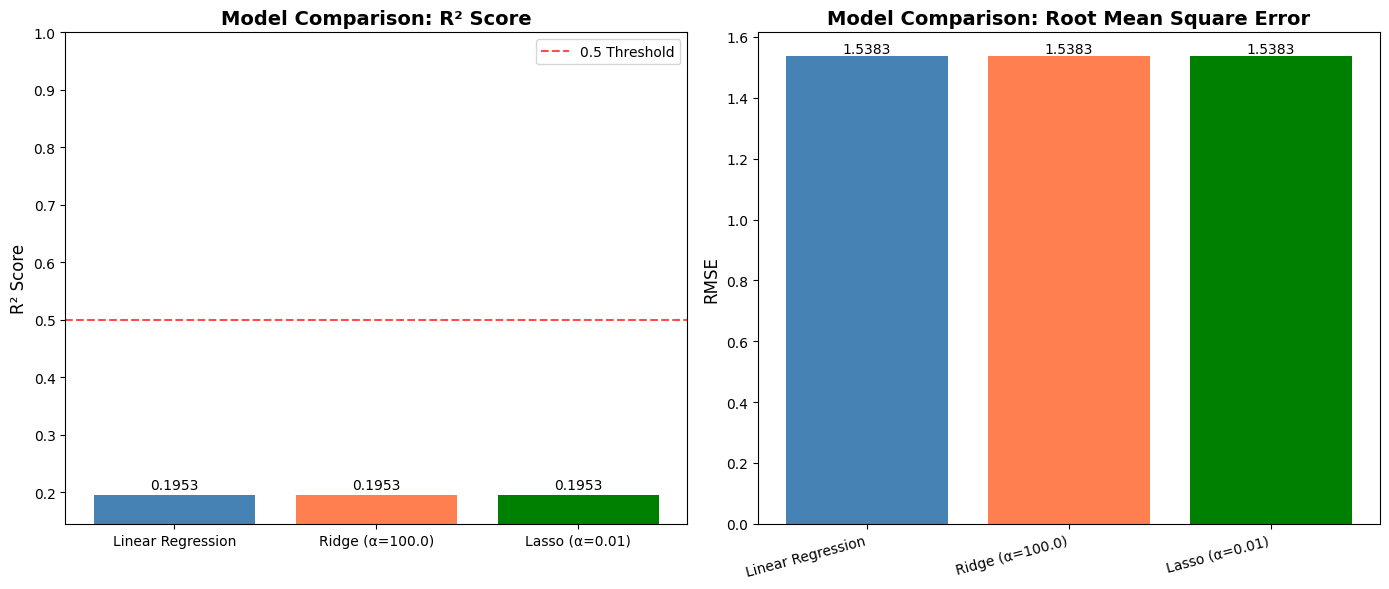

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² Comparison
ax1 = axes[0]
models = comparison_df['Model'].tolist()
r2_scores = comparison_df['R² Score'].tolist()
colors = ['steelblue', 'coral', 'green']
bars = ax1.bar(models, r2_scores, color=colors)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Model Comparison: R² Score', fontsize=14, fontweight='bold')
ax1.set_ylim([min(r2_scores) - 0.05, 1.0])
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='0.5 Threshold')
ax1.legend()
for bar, score in zip(bars, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', fontsize=10)

# RMSE Comparison
ax2 = axes[1]
rmse_scores = comparison_df['RMSE'].tolist()
bars = ax2.bar(models, rmse_scores, color=colors)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Model Comparison: Root Mean Square Error', fontsize=14, fontweight='bold')
for bar, rmse in zip(bars, rmse_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{rmse:.4f}', ha='center', fontsize=10)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Cross-validation

In [49]:
# Select best model for cross-validation
if 'Ridge' in best_r2_model:
    best_model_for_cv = best_ridge_model
    model_name = "Ridge Regression"
elif 'Lasso' in best_r2_model:
    best_model_for_cv = best_lasso_model
    model_name = "Lasso Regression"
else:
    best_model_for_cv = lr_model
    model_name = "Linear Regression"

# Perform 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model_for_cv, X_scaled, y, cv=kfold, scoring='r2')

print(f"\n 5-Fold Cross-Validation Results for {model_name}:")
print(f"   Fold 1: {cv_scores[0]:.4f}")
print(f"   Fold 2: {cv_scores[1]:.4f}")
print(f"   Fold 3: {cv_scores[2]:.4f}")
print(f"   Fold 4: {cv_scores[3]:.4f}")
print(f"   Fold 5: {cv_scores[4]:.4f}")
print(f"\n   Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Compare with test R²
test_r2 = comparison_df.loc[comparison_df['Model'] == best_r2_model, 'R² Score'].values[0]
print(f"   Test R² (from earlier): {test_r2:.4f}")
print(f"   Difference: {abs(cv_scores.mean() - test_r2):.4f}")

# Check for overfitting
if abs(cv_scores.mean() - test_r2) < 0.02:
    print("\n No significant overfitting detected - Model generalizes well!")
else:
    print("\n Potential overfitting detected - Consider simplifying the model")


 5-Fold Cross-Validation Results for Lasso Regression:
   Fold 1: 0.1956
   Fold 2: 0.2017
   Fold 3: 0.1950
   Fold 4: 0.1938
   Fold 5: 0.1998

   Mean CV R²: 0.1972 (+/- 0.0030)
   Test R² (from earlier): 0.1953
   Difference: 0.0019

 No significant overfitting detected - Model generalizes well!


### Cross-validation visual

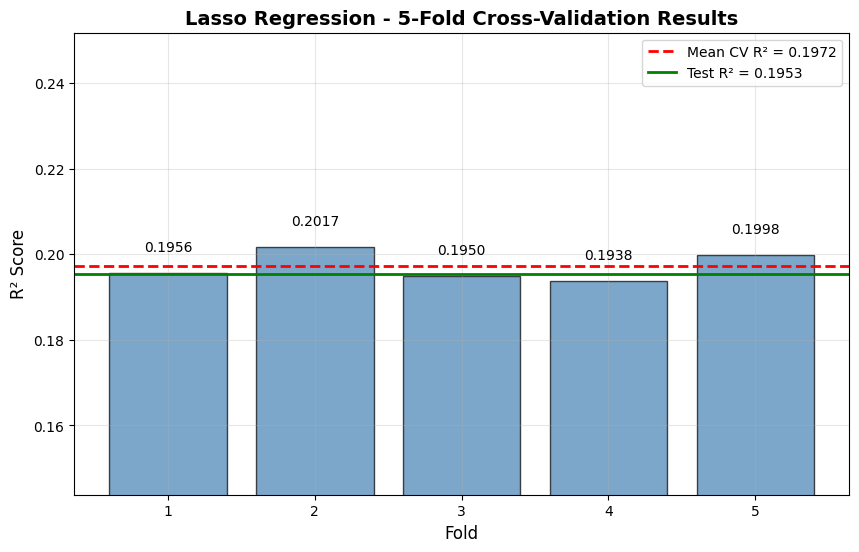

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean CV R² = {cv_scores.mean():.4f}')
ax.axhline(y=test_r2, color='green', linestyle='-', linewidth=2, 
           label=f'Test R² = {test_r2:.4f}')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title(f'{model_name} - 5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
ax.set_ylim([min(cv_scores.min(), test_r2) - 0.05, max(cv_scores.max(), test_r2) + 0.05])
ax.legend()
ax.grid(True, alpha=0.3)

for i, score in enumerate(cv_scores, 1):
    ax.text(i, score + 0.005, f'{score:.4f}', ha='center', fontsize=10)

plt.show()

### Conclusion

Hub connectivity and code-sharing are the key drivers of route popularity.
Airlines looking to enter competitive markets should prioritize hub-to-hub routes and consider strategic partnerships.


---



---



                                              by Aralis Santana


---



---
